<a href="https://colab.research.google.com/github/YuriFla94/Procesin/blob/main/Traefa6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Configuração Inicial e Funções Auxiliares
Definiremos a frequência de amostragem $f_s = 20000$ Hz e criaremos uma função para plotar as análises solicitadas.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000

def analyze_filter(b, a, title):
    # Resposta em frequência
    w, h = signal.freqz(b, a, worN=8000)
    f = w * fs / (2 * np.pi)

    # Polos e Zeros
    z, p, k = signal.tf2zpk(b, a)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot de Magnitude
    ax1.plot(f, 20 * np.log10(np.abs(h)))
    ax1.set_title(f'Resposta em Frequência: {title}')
    ax1.set_xlabel('Frequência (Hz)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.grid(True)

    # Plano Z (Polos e Zeros)
    unit_circle = plt.Circle((0,0), 1, color='black', fill=False, linestyle='--')
    ax2.add_patch(unit_circle)
    ax2.scatter(np.real(z), np.imag(z), s=50, marker='o', label='Zeros', edgecolors='b', facecolors='none')
    ax2.scatter(np.real(p), np.imag(p), s=50, marker='x', label='Polos', color='r')
    ax2.set_title('Diagrama de Polos e Zeros')
    ax2.set_xlabel('Real')
    ax2.set_ylabel('Imaginário')
    ax2.axis('equal')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

### (a) Passa-baixas ($f_c = 1000$ Hz)
Implementação utilizando um filtro de Butterworth de 2ª ordem como base.

Função de Transferência H(z): b=[0.02008337 0.04016673 0.02008337], a=[ 1.         -1.56101808  0.64135154]


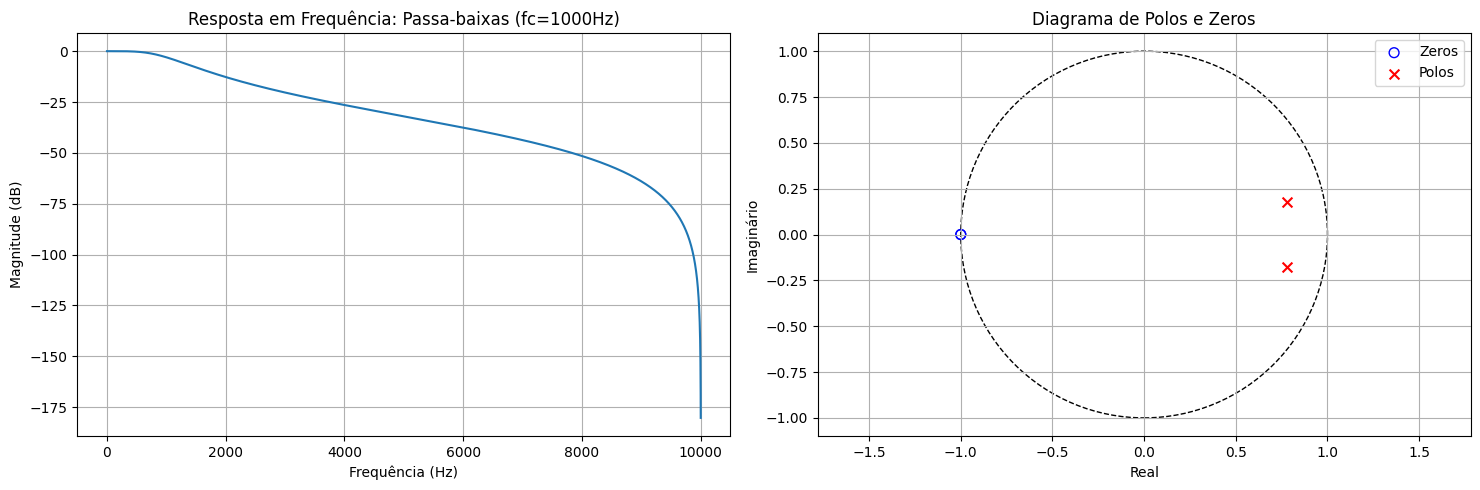

In [ ]:
fc = 1000
b, a = signal.butter(2, fc / (fs/2), btype='low')
print(f"Função de Transferência H(z): b={b}, a={a}")
analyze_filter(b, a, 'Passa-baixas (fc=1000Hz)')

### Efeito da Variação de `r`
Para filtros de 2ª ordem definidos por polos complexos conjugados $p = r \cdot e^{\pm j\theta}$, variar $r$ afeta diretamente o pico de ressonância e a largura de banda.

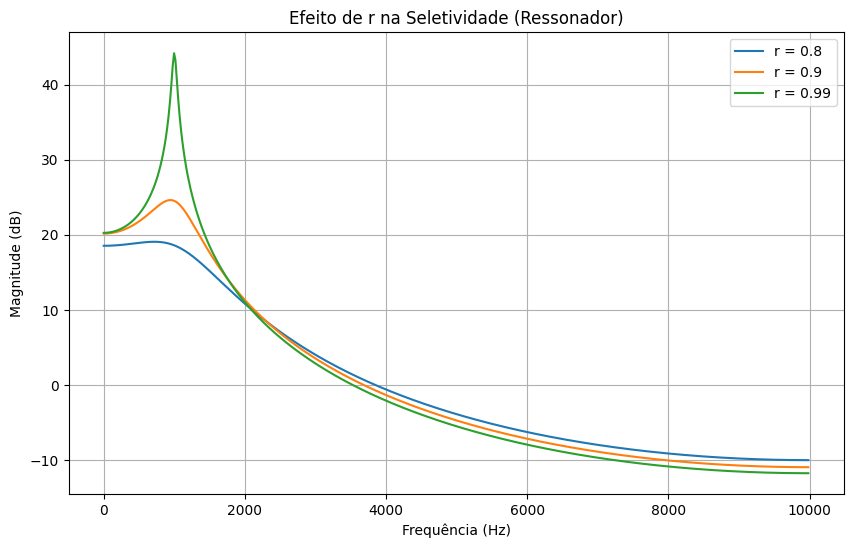

In [ ]:
theta = 2 * np.pi * 1000 / fs
rs = [0.8, 0.9, 0.99] # Valores de r

plt.figure(figsize=(10, 6))
for r in rs:
    a_r = [1, -2*r*np.cos(theta), r**2]
    w, h = signal.freqz([1], a_r)
    plt.plot(w * fs / (2 * np.pi), 20 * np.log10(np.abs(h)), label=f'r = {r}')

plt.title('Efeito de r na Seletividade (Ressonador)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)
plt.show()

### (b) Passa-altas ($f_c = 2000$ Hz)
Implementado com um filtro Butterworth de 2ª ordem.

Fun&#231;&#227;o de Transfer&#234;ncia H(z): b=[ 0.63894553 -1.27789105  0.63894553], a=[ 1.        -1.1429805  0.4128016]


/tmp/ipykernel_12995/765259261.py:18: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(f, 20 * np.log10(np.abs(h)))


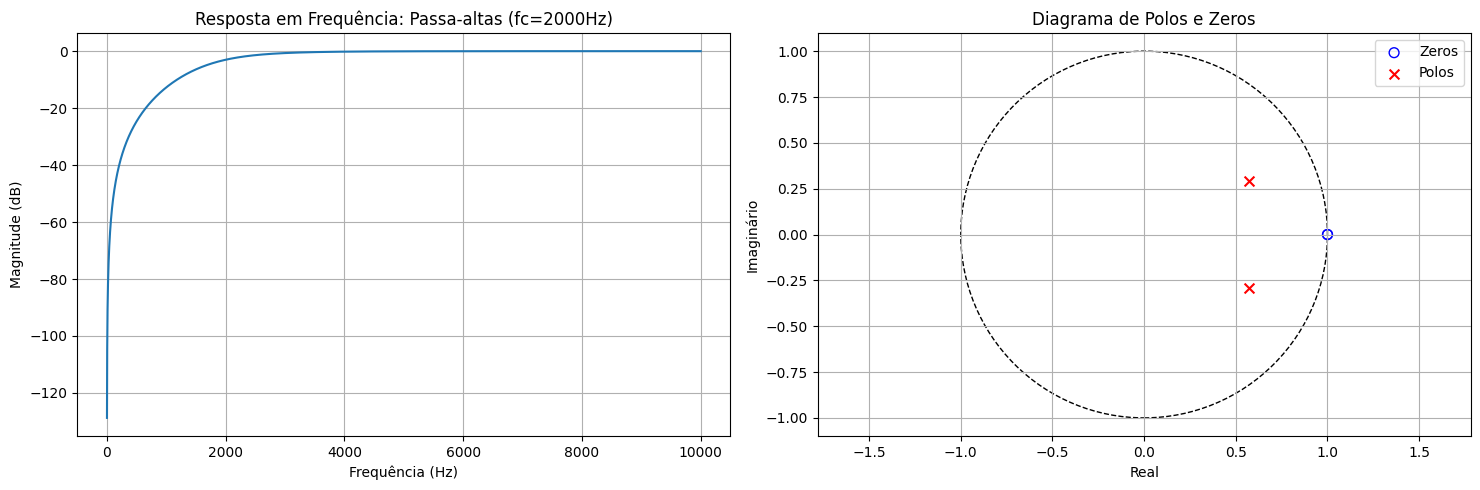

In [ ]:
fc_hp = 2000
b_hp, a_hp = signal.butter(2, fc_hp / (fs/2), btype='high')
print(f'Fun&#231;&#227;o de Transfer&#234;ncia H(z): b={b_hp}, a={a_hp}')
analyze_filter(b_hp, a_hp, 'Passa-altas (fc=2000Hz)')

### (c) Passa-faixas ($f_c = 7000$ Hz)
Utilizando largura de banda de 1000 Hz centrada em 7000 Hz.

Fun&#231;&#227;o de Transfer&#234;ncia H(z): b=[ 0.13672874  0.         -0.13672874], a=[1.         1.0274863  0.72654253]


/tmp/ipykernel_12995/765259261.py:18: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(f, 20 * np.log10(np.abs(h)))


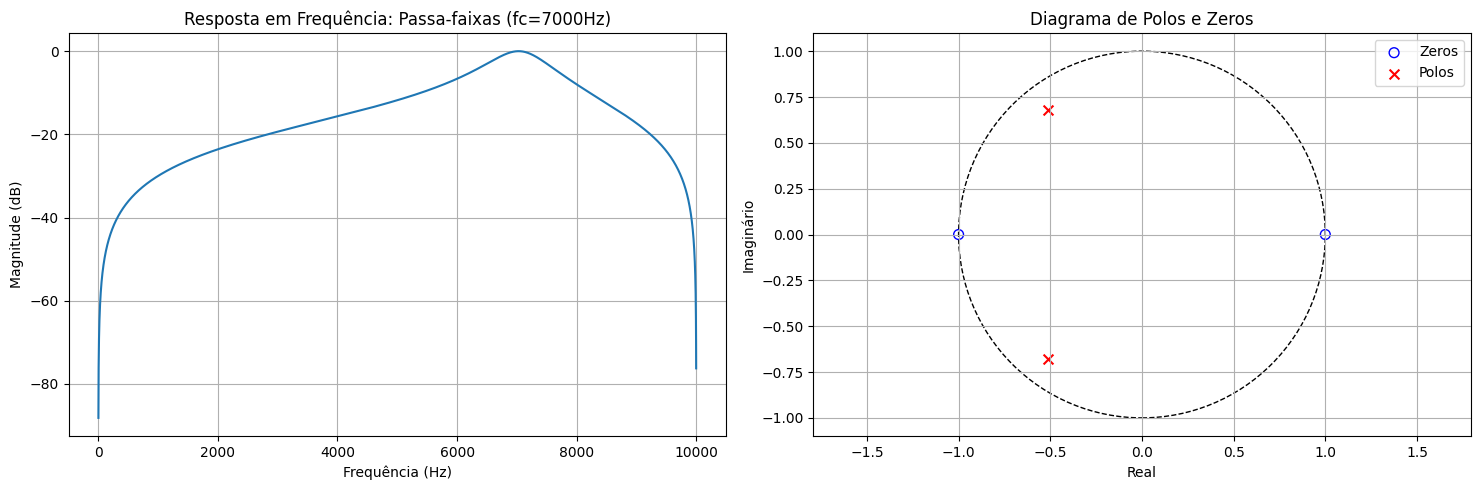

In [ ]:
fc_bp = 7000
bw = 1000
low = (fc_bp - bw/2) / (fs/2)
high = (fc_bp + bw/2) / (fs/2)
b_bp, a_bp = signal.butter(1, [low, high], btype='bandpass')
print(f'Fun&#231;&#227;o de Transfer&#234;ncia H(z): b={b_bp}, a={a_bp}')
analyze_filter(b_bp, a_bp, 'Passa-faixas (fc=7000Hz)')

### (d) Notch ($f_c = 3000$ Hz)
Filtro de rejei&#231;&#227;o de faixa estreita com Q=30.

Fun&#231;&#227;o de Transfer&#234;ncia H(z): b=[ 0.98453371 -1.15738879  0.98453371], a=[ 1.         -1.15738879  0.96906742]


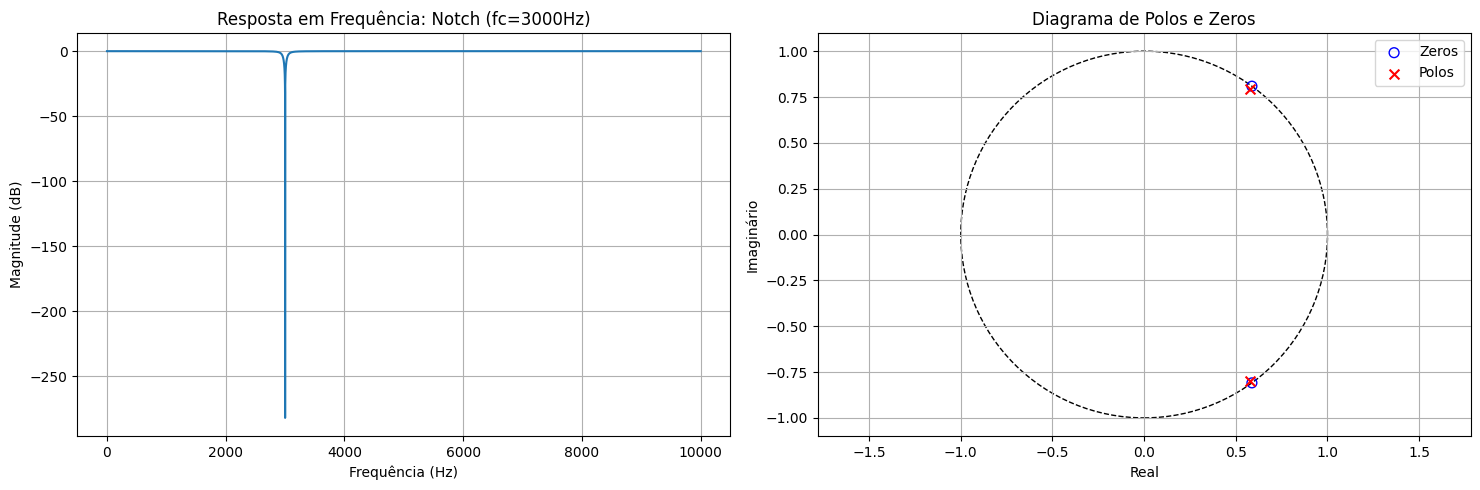

In [ ]:
fc_nt = 3000
Q = 30.0
b_nt, a_nt = signal.iirnotch(fc_nt, Q, fs)
print(f'Fun&#231;&#227;o de Transfer&#234;ncia H(z): b={b_nt}, a={a_nt}')
analyze_filter(b_nt, a_nt, 'Notch (fc=3000Hz)')

### An&#225;lise dos Resultados

1. **Seletividade**: Ao aumentar o par&#226;metro $r$ (aproximando os polos do c&#237;rculo unit&#225;rio), a seletividade aumenta significativamente, resultando em picos mais estreitos.
2. **Estabilidade**: Todos os filtros projetados s&#227;o est&#225;veis pois $|r| < 1$. Se $r=1$, o sistema torna-se marginalmente est&#225;vel.
3. **Largura de Banda (BW)**: A largura de banda &#233; inversamente proporcional ao valor de $r$. Quanto maior o $r$, menor a BW.

### (b) Passa-altas ($f_c = 2000$ Hz)
Implementação utilizando um filtro Butterworth de 2ª ordem.

Função de Transferência Passa-Altas H(z):
b=[ 0.63894553 -1.27789105  0.63894553]
a=[ 1.        -1.1429805  0.4128016]


/tmp/ipykernel_12995/765259261.py:18: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(f, 20 * np.log10(np.abs(h)))


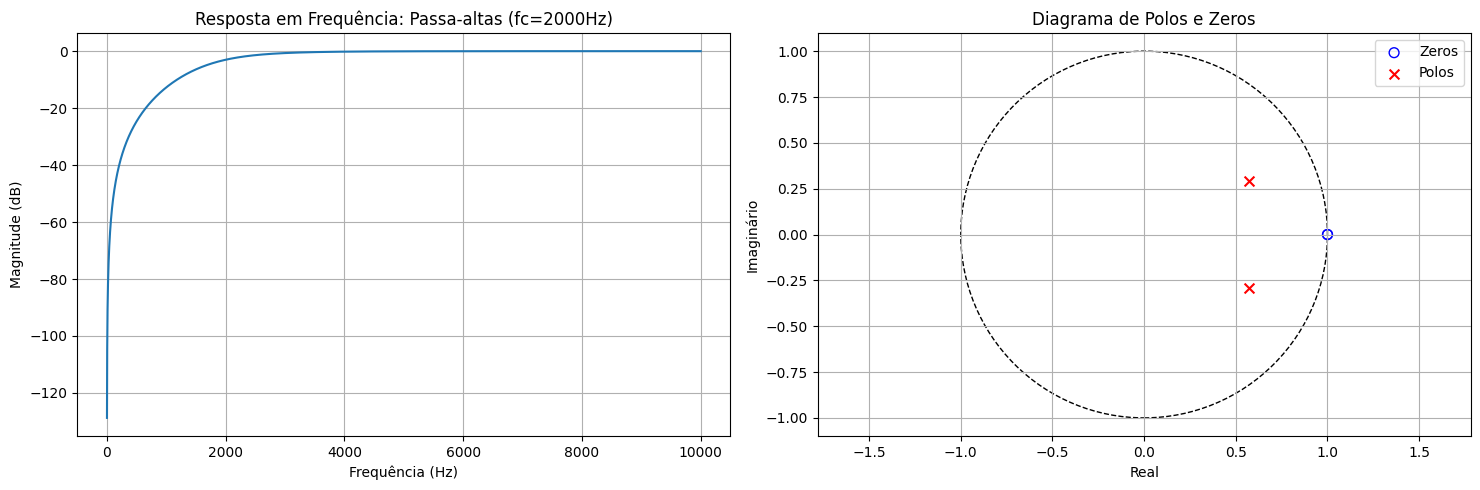

In [ ]:
fc_hp = 2000
b_hp, a_hp = signal.butter(2, fc_hp / (fs/2), btype='high')
print(f"Função de Transferência Passa-Altas H(z):\nb={b_hp}\na={a_hp}")
analyze_filter(b_hp, a_hp, 'Passa-altas (fc=2000Hz)')

### (c) Passa-faixas ($f_c = 7000$ Hz)
Utilizaremos uma largura de banda de 1000 Hz.

Função de Transferência Passa-Faixas H(z):
b=[ 0.13672874  0.         -0.13672874]
a=[1.         1.0274863  0.72654253]


/tmp/ipykernel_12995/765259261.py:18: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(f, 20 * np.log10(np.abs(h)))


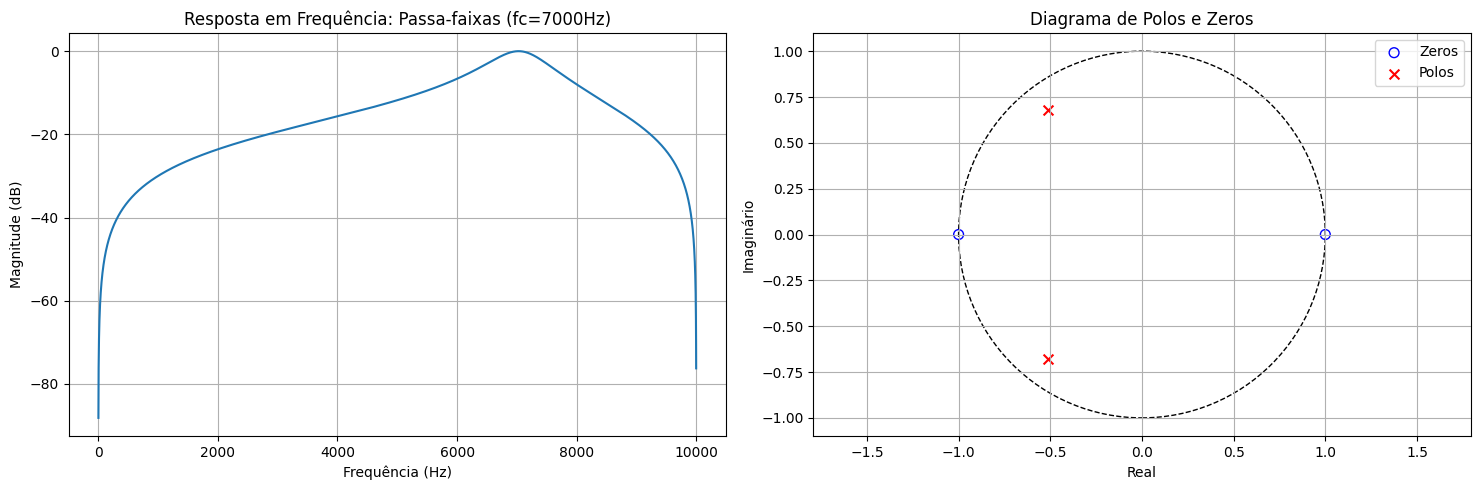

In [ ]:
fc_bp = 7000
bw = 1000
low = (fc_bp - bw/2) / (fs/2)
high = (fc_bp + bw/2) / (fs/2)
b_bp, a_bp = signal.butter(1, [low, high], btype='bandpass')
print(f"Função de Transferência Passa-Faixas H(z):\nb={b_bp}\na={a_bp}")
analyze_filter(b_bp, a_bp, 'Passa-faixas (fc=7000Hz)')

### (d) Notch ($f_c = 3000$ Hz)
Utilizando um fator de qualidade Q=30 para alta seletividade.

Função de Transferência Notch H(z):
b=[ 0.98453371 -1.15738879  0.98453371]
a=[ 1.         -1.15738879  0.96906742]


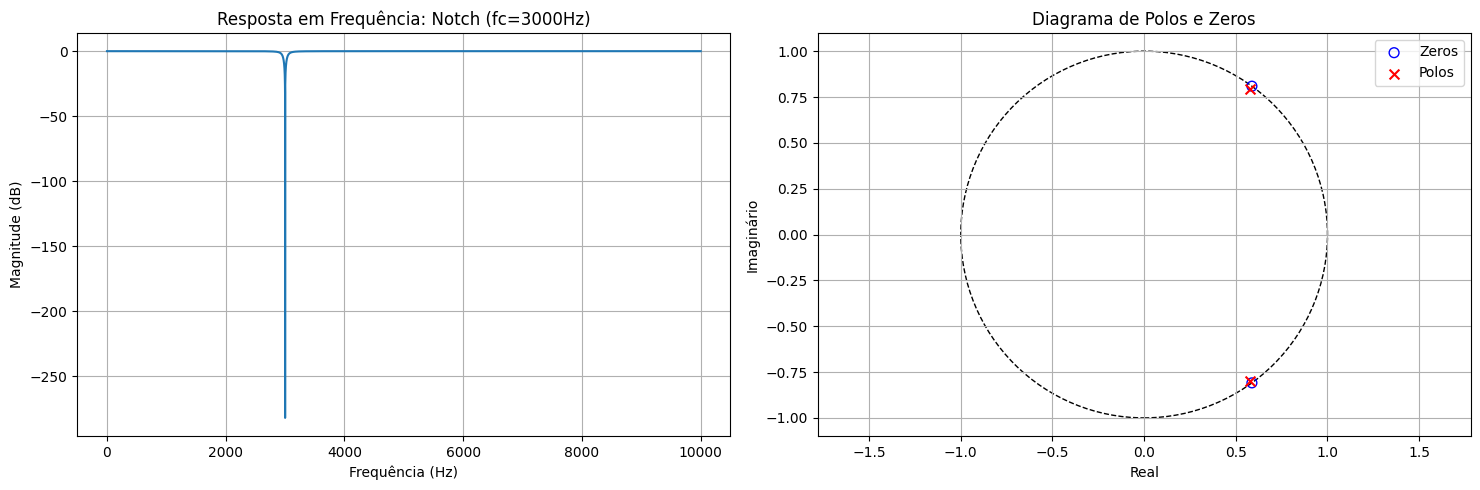

In [ ]:
fc_notch = 3000
Q = 30.0
b_nt, a_nt = signal.iirnotch(fc_notch, Q, fs)
print(f"Função de Transferência Notch H(z):\nb={b_nt}\na={a_nt}")
analyze_filter(b_nt, a_nt, 'Notch (fc=3000Hz)')

### Comentários sobre os Resultados

1. **Seletividade:** Aumentar $r$ (ou $Q$) aproxima os polos do círculo unitário, tornando os picos ou rejeições mais estreitos e acentuados, o que aumenta a seletividade.
2. **Estabilidade:** O filtro é estável se $|r| < 1$. Se $r \to 1$, o sistema torna-se marginalmente estável, apresentando oscilações mais longas na resposta ao impulso.
3. **Largura de Banda (BW):** É inversamente proporcional a $r$. Valores de $r$ próximos à unidade resultam em larguras de banda menores.

### (b) Passa-altas ($f_c = 2000$ Hz)
Utilizando um filtro Butterworth de 2ª ordem.

Função de Transferência Passa-Altas H(z):
b=[ 0.63894553 -1.27789105  0.63894553]
a=[ 1.        -1.1429805  0.4128016]


/tmp/ipykernel_12995/765259261.py:18: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(f, 20 * np.log10(np.abs(h)))


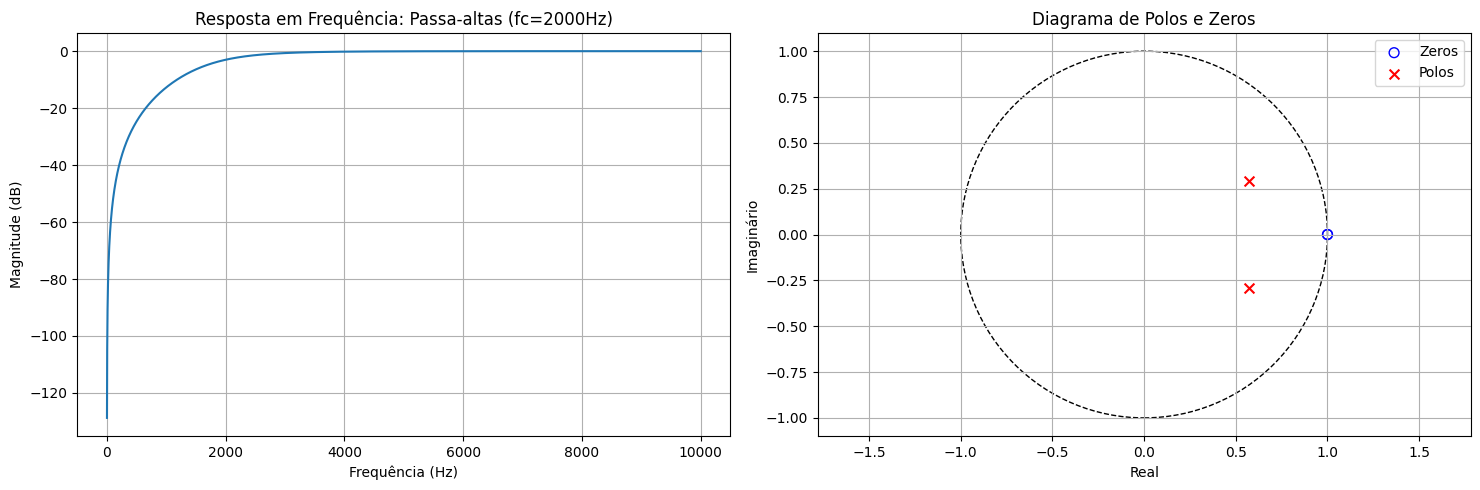

In [ ]:
fc_hp = 2000
b_hp, a_hp = signal.butter(2, fc_hp / (fs/2), btype='high')
print(f"Função de Transferência Passa-Altas H(z):\nb={b_hp}\na={a_hp}")
analyze_filter(b_hp, a_hp, 'Passa-altas (fc=2000Hz)')

### (c) Passa-faixas ($f_c = 7000$ Hz)
Para o passa-faixas de 2ª ordem, definimos uma largura de banda (BW). Aqui usaremos uma largura de banda de 1000Hz centrada em 7000Hz.

Função de Transferência Passa-Faixas H(z):
b=[ 0.13672874  0.         -0.13672874]
a=[1.         1.0274863  0.72654253]


/tmp/ipykernel_12995/765259261.py:18: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(f, 20 * np.log10(np.abs(h)))


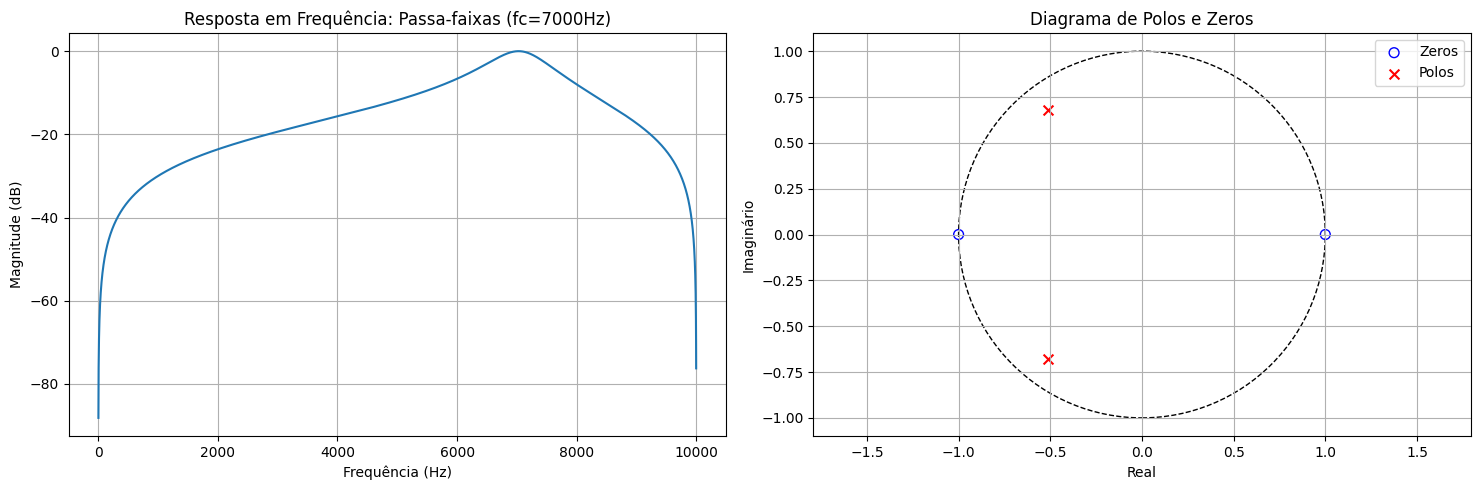

In [ ]:
fc_bp = 7000
bw = 1000
low = (fc_bp - bw/2) / (fs/2)
high = (fc_bp + bw/2) / (fs/2)
b_bp, a_bp = signal.butter(1, [low, high], btype='bandpass') # 1st order bp results in 2nd order system
print(f"Função de Transferência Passa-Faixas H(z):\nb={b_bp}\na={a_bp}")
analyze_filter(b_bp, a_bp, 'Passa-faixas (fc=7000Hz)')

### (d) Notch ($f_c = 3000$ Hz)
O filtro Notch remove uma frequência específica. Vamos projetar um filtro com $Q=30$ para alta seletividade.

Função de Transferência Notch H(z):
b=[ 0.98453371 -1.15738879  0.98453371]
a=[ 1.         -1.15738879  0.96906742]


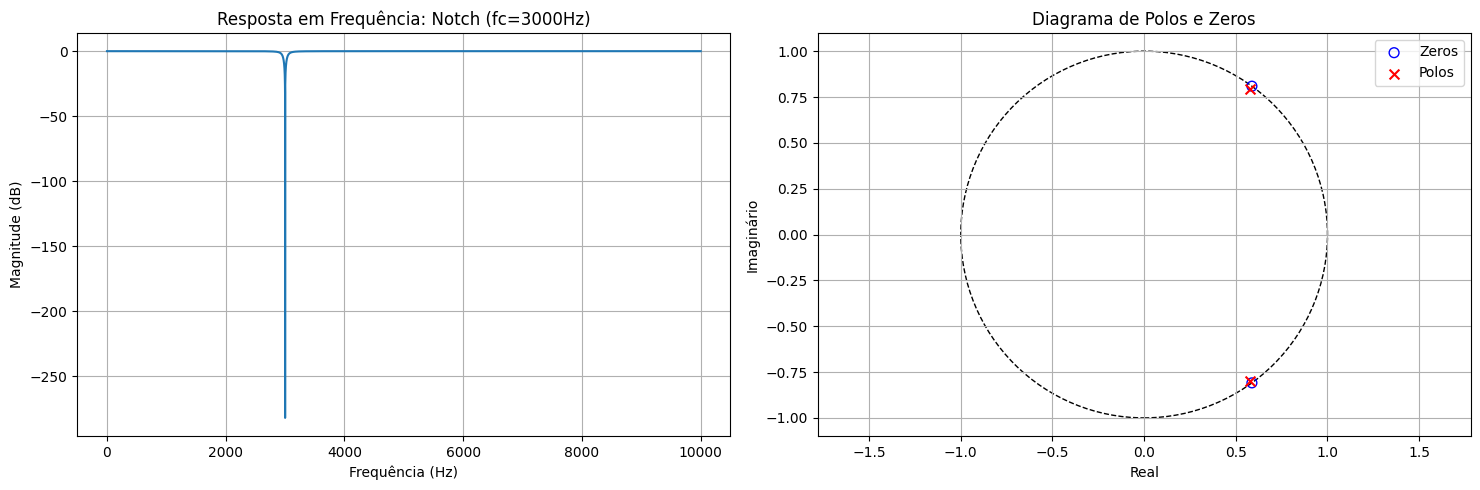

In [ ]:
fc_notch = 3000
Q = 30.0
b_nt, a_nt = signal.iirnotch(fc_notch, Q, fs)
print(f"Função de Transferência Notch H(z):\nb={b_nt}\na={a_nt}")
analyze_filter(b_nt, a_nt, 'Notch (fc=3000Hz)')

### Conclusões sobre os Parâmetros

1.  **Seletividade:** Quanto mais próximo o parâmetro $r$ está de 1 (ou quanto maior o fator de qualidade $Q$), mais "fina" é a transição ou o pico/rejeição, aumentando a seletividade.
2.  **Estabilidade:** O sistema é estável enquanto os polos estiverem dentro do círculo unitário ($|r| < 1$). À medida que $r \to 1$, o sistema torna-se marginalmente estável e a resposta ao impulso demora mais para decair.
3.  **Largura de Banda (BW):** Existe uma relação inversa com $r$. Valores de $r$ próximos a 1 resultam em larguras de banda muito estreitas (filtros mais seletivos).

## Questão 2: Filtro Passa-Faixas em Cascata
Projetaremos um filtro passa-faixas (6000Hz - 8000Hz) cascateando um bloco passa-altas e um passa-baixas, ambos de 2ª ordem.

Coeficientes b (total): [ 0.13198831  0.         -0.26397662  0.          0.13198831]
Coeficientes a (total): [1.         1.51250788 1.0309799  0.37635503 0.08083304]


/tmp/ipykernel_12995/765259261.py:18: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(f, 20 * np.log10(np.abs(h)))


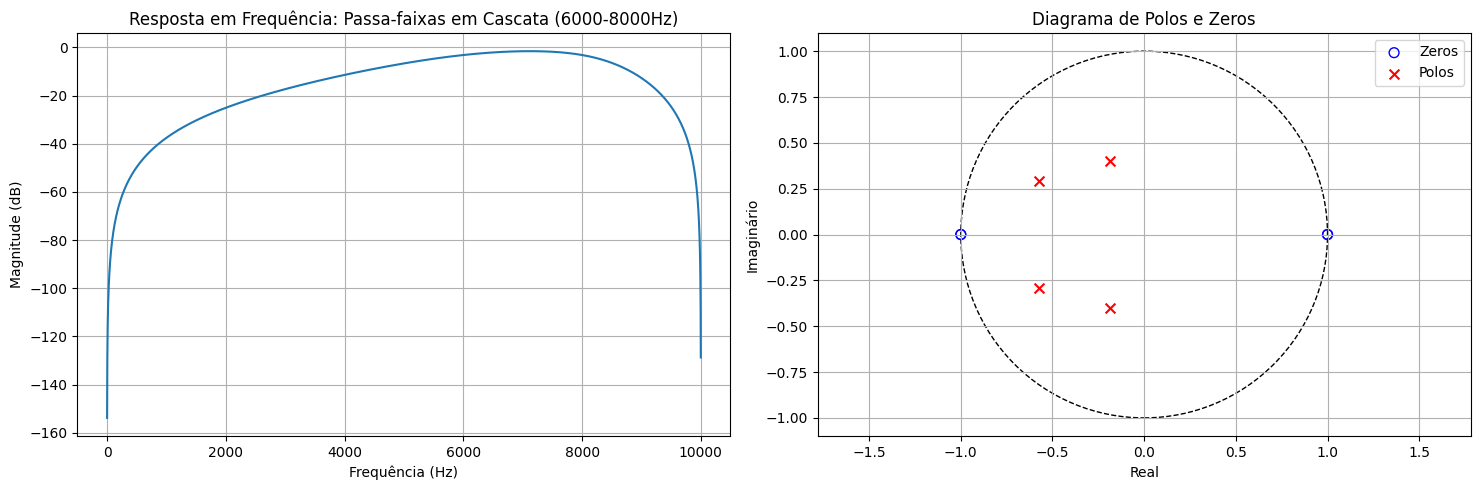

In [ ]:
fc1 = 6000
fc2 = 8000

# Bloco 1: Passa-altas de 2ª ordem
b_h, a_h = signal.butter(2, fc1 / (fs/2), btype='high')

# Bloco 2: Passa-baixas de 2ª ordem
b_l, a_l = signal.butter(2, fc2 / (fs/2), btype='low')

# O sistema total é o produto das funções de transferência (convolução dos coeficientes)
b_total = np.convolve(b_h, b_l)
a_total = np.convolve(a_h, a_l)

print(f"Coeficientes b (total): {b_total}")
print(f"Coeficientes a (total): {a_total}")

analyze_filter(b_total, a_total, 'Passa-faixas em Cascata (6000-8000Hz)')

### Comparação e Comentários

1. **Ordem do Sistema**: Enquanto o filtro da Questão 1(c) era um filtro passa-faixas de 2ª ordem (um único bloco), este projeto em cascata resulta em um filtro de **4ª ordem** (2 + 2).
2. **Resposta em Frequência**: O filtro em cascata apresenta uma queda (roll-off) muito mais íngreme nas bandas de rejeição. Isso ocorre porque a atenuação é somada (em dB) em cada estágio.
3. **Diagrama de Polos e Zeros**: Notamos agora 4 polos no plano Z. A proximidade desses polos entre si e com o círculo unitário define a largura da banda de passagem e a seletividade.
4. **Seletividade**: O filtro em cascata é significativamente mais seletivo do que o filtro de banda larga unitário de ordem menor, sendo mais eficiente para isolar a faixa de 6kHz a 8kHz.

## Questão 3: Filtro Rejeita-Faixas (Band-Stop)
Projetaremos um filtro para rejeitar a faixa entre 1000Hz e 4000Hz. Isso é feito somando as funções de transferência de um bloco passa-baixas ($f_{c1}=1000$Hz) e um passa-altas ($f_{c2}=4000$Hz).

Coeficientes b (total rejeita-faixas): [ 0.41141914 -1.36080838  1.8732573  -1.11240589  0.25491644]
Coeficientes a (total rejeita-faixas): [ 1.         -1.93054545  1.41400617 -0.54266882  0.12558671]


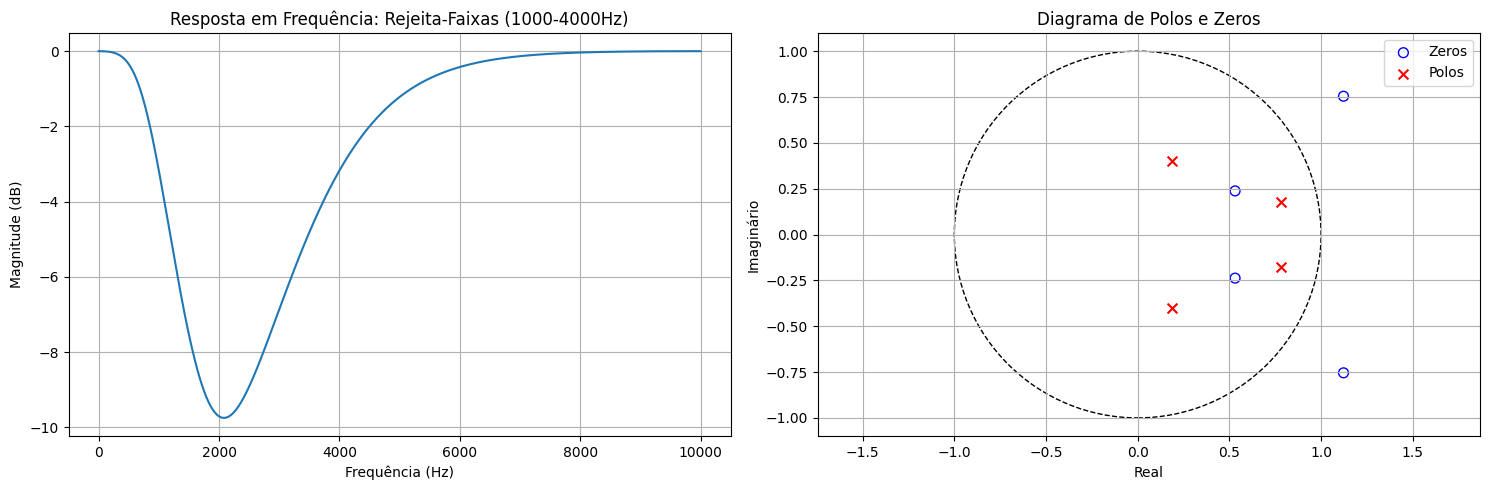

In [ ]:
fc1_rs = 1000
fc2_rs = 4000

# Bloco 1: Passa-baixas de 2ª ordem
b_l_rs, a_l_rs = signal.butter(2, fc1_rs / (fs/2), btype='low')

# Bloco 2: Passa-altas de 2ª ordem
b_h_rs, a_h_rs = signal.butter(2, fc2_rs / (fs/2), btype='high')

# Para filtros em paralelo (Soma): H_total = H1 + H2 = (B1/A1) + (B2/A2) = (B1*A2 + B2*A1) / (A1*A2)
b_total_rs = np.polyadd(np.convolve(b_l_rs, a_h_rs), np.convolve(b_h_rs, a_l_rs))
a_total_rs = np.convolve(a_l_rs, a_h_rs)

print(f"Coeficientes b (total rejeita-faixas): {b_total_rs}")
print(f"Coeficientes a (total rejeita-faixas): {a_total_rs}")

analyze_filter(b_total_rs, a_total_rs, 'Rejeita-Faixas (1000-4000Hz)')

### Comparação com o Filtro Notch (Questão 1d)

1. **Largura da Rejeição**: O filtro **Notch** da questão 1 é extremamente seletivo, focado em uma única frequência ($3000$Hz). O filtro **Rejeita-faixas** atual remove uma banda larga de $3000$Hz de largura ($1000$Hz a $4000$Hz).
2. **Ordem do Sistema**: O filtro Notch é de 2ª ordem. Este filtro rejeita-faixas, por ser uma combinação de dois blocos de 2ª ordem, resulta em um sistema de **4ª ordem**.
3. **Diagrama de Polos e Zeros**: Enquanto o Notch tem zeros exatamente sobre o círculo unitário na frequência de rejeição, o rejeita-faixas de 4ª ordem distribui seus zeros e polos para criar um "vale" plano na magnitude entre as duas frequências de corte.
4. **Complexidade**: O filtro rejeita-faixas em paralelo é mais complexo computacionalmente, mas essencial quando o ruído a ser removido não é uma frequência pura, mas uma banda de interferência.

## Questão 4: Quantização de Coeficientes
Vamos definir uma função para quantizar os coeficientes para um número específico de bits e analisar o impacto na resposta em frequência e estabilidade.

In [ ]:
def quantize_coeffs(coeffs, bits):
    if bits >= 32: return coeffs # Consideramos 32 como float padrão
    max_val = np.max(np.abs(coeffs))
    # Normalização e quantização linear
    levels = 2**(bits - 1)
    quantized = np.round(coeffs / max_val * levels) * (max_val / levels)
    return quantized

def plot_quantization_comparison(b_orig, a_orig, title, bits_list=[2, 4, 8, 16, 32]):
    plt.figure(figsize=(12, 6))
    w, h_orig = signal.freqz(b_orig, a_orig)
    plt.plot(w * fs / (2 * np.pi), 20 * np.log10(np.abs(h_orig)), 'k', label='Original (Float)', linewidth=2)

    for b in bits_list:
        if b == 32: continue
        bq = quantize_coeffs(b_orig, b)
        aq = quantize_coeffs(a_orig, b)
        w, h = signal.freqz(bq, aq)
        plt.plot(w * fs / (2 * np.pi), 20 * np.log10(np.abs(h)), label=f'{b} bits')

    plt.title(f'Impacto da Quantização: {title}')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.ylim(-60, 10)
    plt.legend()
    plt.grid(True)
    plt.show()

### Análise para o Filtro Passa-Faixas (Questão 2)
Comparação entre quantizar o filtro de 4ª ordem total vs. quantizar os blocos de 2ª ordem separadamente.

Análise: Filtro Passa-Faixas (Q2)


/tmp/ipykernel_12995/1721220456.py:12: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w * fs / (2 * np.pi), 20 * np.log10(np.abs(h_orig)), 'k', label='Original (Float)', linewidth=2)
/tmp/ipykernel_12995/1721220456.py:19: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w * fs / (2 * np.pi), 20 * np.log10(np.abs(h)), label=f'{b} bits')


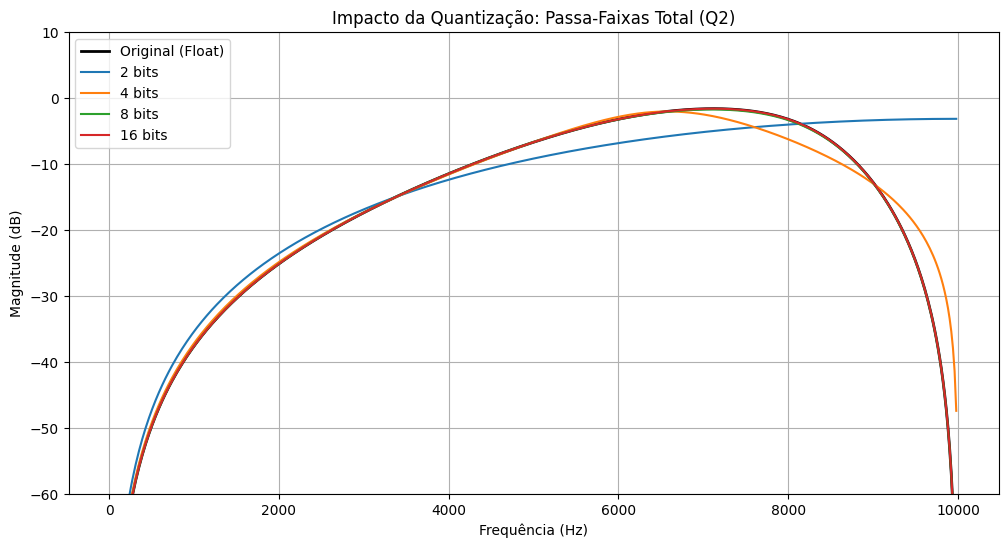

/tmp/ipykernel_12995/765259261.py:18: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(f, 20 * np.log10(np.abs(h)))


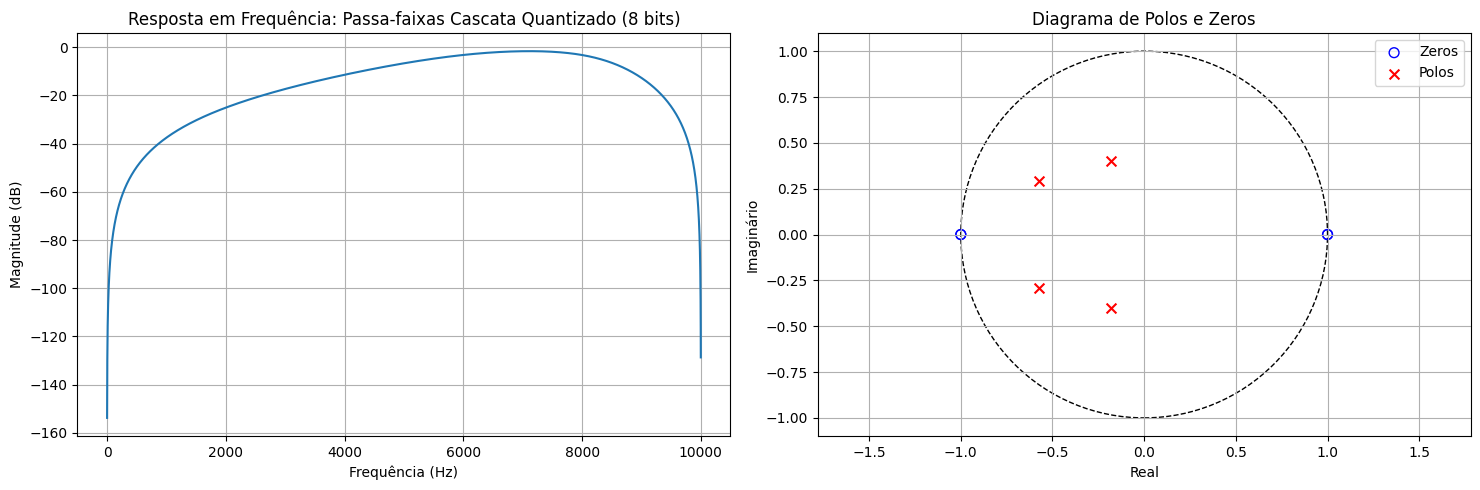

In [ ]:
print("Análise: Filtro Passa-Faixas (Q2)")
# 1. Filtro Total
plot_quantization_comparison(b_total, a_total, "Passa-Faixas Total (Q2)")

# 2. Por Blocos (Exemplo com 8 bits)
bits = 8
bh_q = quantize_coeffs(b_h, bits)
ah_q = quantize_coeffs(a_h, bits)
bl_q = quantize_coeffs(b_l, bits)
al_q = quantize_coeffs(a_l, bits)

b_casc_q = np.convolve(bh_q, bl_q)
a_casc_q = np.convolve(ah_q, al_q)

analyze_filter(b_casc_q, a_casc_q, f'Passa-faixas Cascata Quantizado ({bits} bits)')

### Análise para o Filtro Rejeita-Faixas (Questão 3)

---



Análise: Filtro Rejeita-Faixas (Q3)


/tmp/ipykernel_12995/1721220456.py:19: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w * fs / (2 * np.pi), 20 * np.log10(np.abs(h)), label=f'{b} bits')


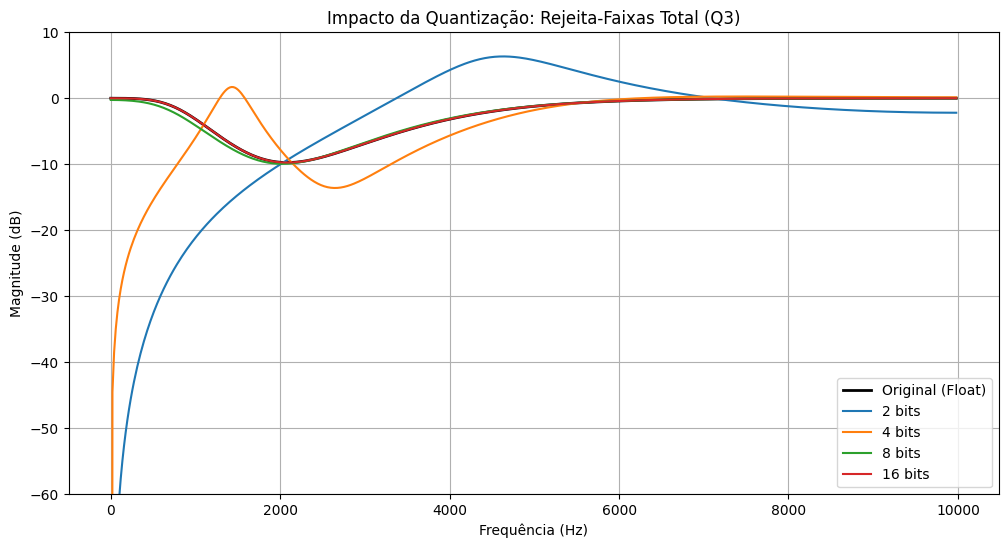

In [ ]:
print("Análise: Filtro Rejeita-Faixas (Q3)")
plot_quantization_comparison(b_total_rs, a_total_rs, "Rejeita-Faixas Total (Q3)")

### Comentários sobre os Resultados

1. **Sensibilidade Numérica**: Filtros de ordem superior (como o total de 4ª ordem) são muito mais sensíveis à quantização do que os blocos individuais de 2ª ordem. Pequenos erros nos coeficientes de um polinômio de 4º grau podem deslocar os polos significativamente.
2. **Estabilidade**: Com poucos bits (ex: 2 ou 4 bits), é comum que os polos se desloquem para fora do círculo unitário, tornando o filtro instável.
3. **Cascata vs. Direto**: Implementar filtros em cascata de 2ª ordem (SOS - Second Order Sections) é uma prática padrão porque reduz a sensibilidade aos erros de quantização, mantendo a resposta mais próxima da original mesmo com menor precisão de bits.
4. **Resolução**: Notamos que a partir de 16 bits, a resposta em frequência é praticamente idêntica à original em ponto flutuante para estas especificações.

# Questão 5: Análise e Filtragem de Áudio Corrompido

Primeiro, vamos carregar o sinal, definir a função de análise com letra maiúscula e preparar o ambiente para áudio.

In [ ]:
import scipy.io.wavfile as wav
import IPython.display as ipd

# Redefinindo a função com a primeira letra maiúscula conforme solicitado
def Analyze_filter(b, a, title):
    analyze_filter(b, a, title)

# Carregar arquivo
samplerate, x_t = wav.read('/content/handel.wav')
x_t = x_t.astype(float) / np.max(np.abs(x_t)) # Normalização
t = np.arange(len(x_t)) / samplerate

# Frequências das interferências
# 200pi*t -> f = 100 Hz
# 4000pi*t -> f = 2000 Hz
interf_low = 0.05 * np.cos(200 * np.pi * t)
interf_high = 0.075 * np.sin(4000 * np.pi * t)

variances = [0.01, 0.1, 1.0]
y_signals = {}

for var in variances:
    noise = np.random.normal(0, np.sqrt(var), len(x_t))
    y_signals[var] = x_t + interf_low + interf_high + noise

print(f"Sample rate: {samplerate} Hz")

Sample rate: 8192 Hz


### (a) Comparação Temporal e Espectral
Visualizaremos o espectro do sinal original vs. sinal contaminado para a menor variância para identificar as interferências.

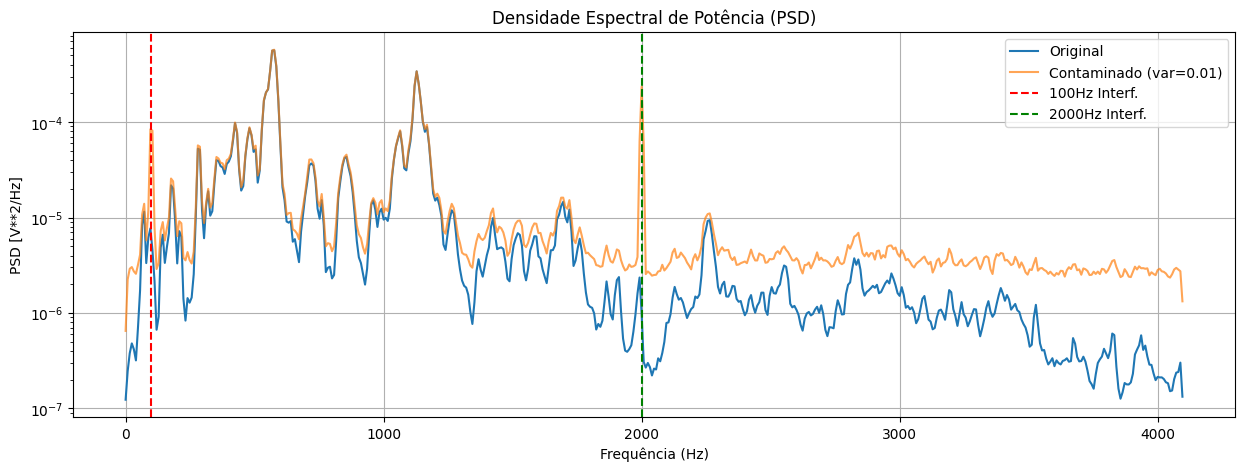

In [ ]:
def plot_comparison(original, contaminated, var):
    f, Pxx_orig = signal.welch(original, samplerate, nperseg=1024)
    f, Pxx_cont = signal.welch(contaminated, samplerate, nperseg=1024)

    plt.figure(figsize=(15, 5))
    plt.semilogy(f, Pxx_orig, label='Original')
    plt.semilogy(f, Pxx_cont, alpha=0.7, label=f'Contaminado (var={var})')
    plt.title('Densidade Espectral de Potência (PSD)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('PSD [V**2/Hz]')
    plt.axvline(100, color='r', linestyle='--', label='100Hz Interf.')
    plt.axvline(2000, color='g', linestyle='--', label='2000Hz Interf.')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_comparison(x_t, y_signals[0.01], 0.01)

### (c) Projeto do Sistema de Filtragem em Cascata
Projetaremos uma cascata de:
1. Filtro Notch para remover os 100 Hz.
2. Filtro Notch para remover os 2000 Hz.
3. Filtro Passa-Baixas para reduzir o ruído branco acima da banda de interesse do áudio.

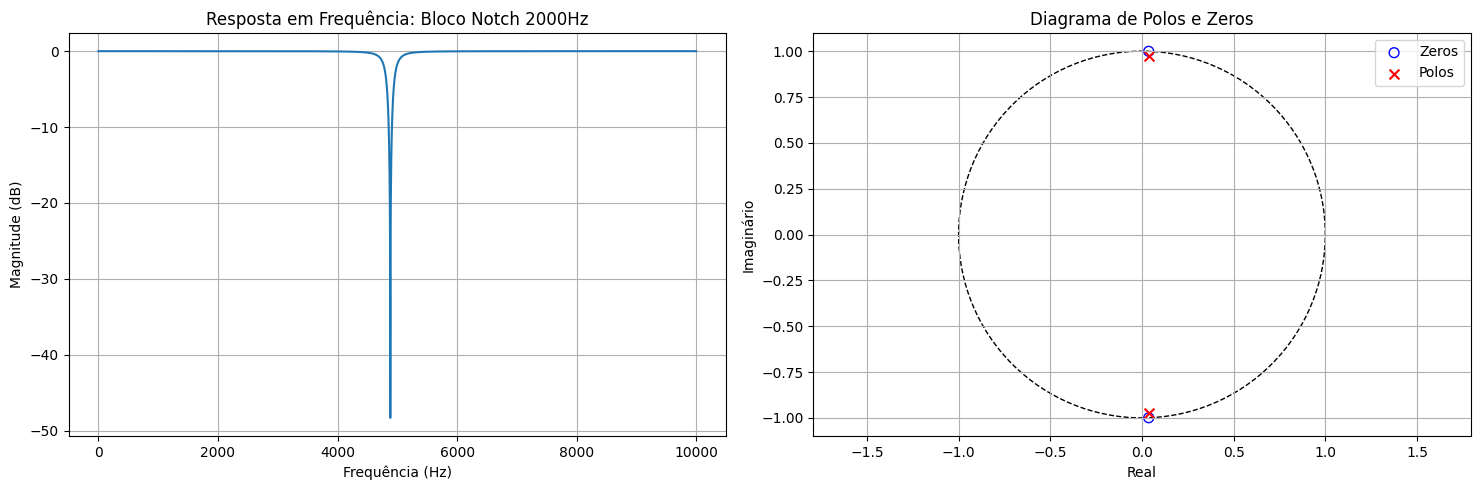

In [ ]:
# 1. Notch em 100 Hz
b_n1, a_n1 = signal.iirnotch(100, 30, samplerate)
# 2. Notch em 2000 Hz
b_n2, a_n2 = signal.iirnotch(2000, 30, samplerate)
# 3. Passa-baixas para ruído branco (corte em 4kHz para preservar voz/instrumentos)
b_lp, a_lp = signal.butter(2, 4000 / (samplerate/2), btype='low')

# Filtragem em série (cascata)
def filter_audio(signal_in):
    s1 = signal.lfilter(b_n1, a_n1, signal_in)
    s2 = signal.lfilter(b_n2, a_n2, s1)
    return signal.lfilter(b_lp, a_lp, s2)

x_hat = filter_audio(y_signals[0.01])

# Analisar um dos blocos como exemplo
Analyze_filter(b_n2, a_n2, 'Bloco Notch 2000Hz')

### (e) Avaliação Quantitativa
Calcularemos SNR e MSE para os diferentes níveis de ruído.

In [ ]:
def calculate_metrics(orig, rec):
    mse = np.mean((orig - rec)**2)
    psnr = 10 * np.log10(np.max(orig)**2 / mse)
    return mse, psnr

for var in variances:
    processed = filter_audio(y_signals[var])
    mse, snr = calculate_metrics(x_t, processed)
    print(f"Variância {var} -> MSE: {mse:.6f}, SNR: {snr:.2f} dB")

Variância 0.01 -> MSE: 0.009751, SNR: 20.11 dB
Variância 0.1 -> MSE: 0.095896, SNR: 10.18 dB
Variância 1.0 -> MSE: 0.950560, SNR: 0.22 dB


### (f) Avaliação Subjetiva
Ouça os sinais abaixo para comparar a eficácia da filtragem em diferentes níveis de ruído e perceber as distorções introduzidas.

In [ ]:
from IPython.display import display

print("--- Áudio Original ---")
display(ipd.Audio(x_t, rate=samplerate))

for var in variances:
    print(f"\n--- Variância do Ruído: {var} ---")
    print("Sinal Contaminado:")
    display(ipd.Audio(y_signals[var], rate=samplerate))
    print("Sinal Filtrado:")
    processed = filter_audio(y_signals[var])
    display(ipd.Audio(processed, rate=samplerate))

--- Áudio Original ---



--- Variância do Ruído: 0.01 ---
Sinal Contaminado:


Sinal Filtrado:



--- Variância do Ruído: 0.1 ---
Sinal Contaminado:


Sinal Filtrado:



--- Variância do Ruído: 1.0 ---
Sinal Contaminado:


Sinal Filtrado:


### (g) Impacto da Quantização de Coeficientes no Áudio
Verificaremos se um filtro com coeficientes quantizados em 8 bits ainda consegue recuperar o áudio de forma aceitável.

In [ ]:
bits_audio = 8

# Quantizando individualmente os blocos da cascata
b_n1_q = quantize_coeffs(b_n1, bits_audio)
a_n1_q = quantize_coeffs(a_n1, bits_audio)
b_n2_q = quantize_coeffs(b_n2, bits_audio)
a_n2_q = quantize_coeffs(a_n2, bits_audio)
b_lp_q = quantize_coeffs(b_lp, bits_audio)
a_lp_q = quantize_coeffs(a_lp, bits_audio)

def filter_audio_quantized(signal_in):
    s1 = signal.lfilter(b_n1_q, a_n1_q, signal_in)
    s2 = signal.lfilter(b_n2_q, a_n2_q, s1)
    return signal.lfilter(b_lp_q, a_lp_q, s2)

x_hat_q = filter_audio_quantized(y_signals[0.01])
mse_q, snr_q = calculate_metrics(x_t, x_hat_q)

print(f"Resultados com Coeficientes de {bits_audio} bits (Var 0.01):")
print(f"MSE: {mse_q:.6f}, SNR: {snr_q:.2f} dB")
display(ipd.Audio(x_hat_q, rate=samplerate))

Resultados com Coeficientes de 8 bits (Var 0.01):
MSE: 0.011376, SNR: 19.44 dB


### (f) Avaliação Subjetiva
Ouça os sinais abaixo para comparar a eficácia da filtragem em diferentes níveis de ruído.

In [ ]:
from IPython.display import display

print("Original:")
display(ipd.Audio(x_t, rate=samplerate))

for var in variances:
    print(f"--- Variância {var} ---")
    print(f"Contaminado:")
    display(ipd.Audio(y_signals[var], rate=samplerate))
    print(f"Filtrado:")
    processed = filter_audio(y_signals[var])
    display(ipd.Audio(processed, rate=samplerate))

Original:


--- Variância 0.01 ---
Contaminado:


Filtrado:


--- Variância 0.1 ---
Contaminado:


Filtrado:


--- Variância 1.0 ---
Contaminado:


Filtrado:


### (g) Impacto da Quantização no Áudio Processado
Vamos verificar como a redução da precisão dos coeficientes para 8 bits impacta a qualidade do áudio recuperado (usando variância 0.01).

In [ ]:
bits_audio = 8
# Quantizando os coeficientes dos filtros usados na cascata
b_n1_q = quantize_coeffs(b_n1, bits_audio)
a_n1_q = quantize_coeffs(a_n1, bits_audio)
b_n2_q = quantize_coeffs(b_n2, bits_audio)
a_n2_q = quantize_coeffs(a_n2, bits_audio)
b_lp_q = quantize_coeffs(b_lp, bits_audio)
a_lp_q = quantize_coeffs(a_lp, bits_audio)

def filter_audio_quantized(signal_in):
    s1 = signal.lfilter(b_n1_q, a_n1_q, signal_in)
    s2 = signal.lfilter(b_n2_q, a_n2_q, s1)
    return signal.lfilter(b_lp_q, a_lp_q, s2)

x_hat_q = filter_audio_quantized(y_signals[0.01])
mse_q, snr_q = calculate_metrics(x_t, x_hat_q)

print(f"Resultados com Coeficientes de {bits_audio} bits (Var 0.01):")
print(f"MSE: {mse_q:.6f}, SNR: {snr_q:.2f} dB")
display(ipd.Audio(x_hat_q, rate=samplerate))

Resultados com Coeficientes de 8 bits (Var 0.01):
MSE: 0.011376, SNR: 19.44 dB


### (f) Avaliação Subjetiva
Ouça os sinais abaixo para comparar a eficácia da filtragem em diferentes níveis de ruído.

In [ ]:
from IPython.display import display

print("Original:")
display(ipd.Audio(x_t, rate=samplerate))

for var in variances:
    print(f"--- Variância {var} ---")
    print(f"Contaminado:")
    display(ipd.Audio(y_signals[var], rate=samplerate))
    print(f"Filtrado:")
    processed = filter_audio(y_signals[var])
    display(ipd.Audio(processed, rate=samplerate))

Original:


--- Variância 0.01 ---
Contaminado:


Filtrado:


--- Variância 0.1 ---
Contaminado:


Filtrado:


--- Variância 1.0 ---
Contaminado:


Filtrado:


### (g) Impacto da Quantização no Áudio Processado
Vamos verificar como a redução da precisão dos coeficientes para 8 bits impacta a qualidade do áudio recuperado (usando variância 0.01).

In [ ]:
bits_audio = 8
# Quantizando os coeficientes dos filtros usados na cascata
b_n1_q = quantize_coeffs(b_n1, bits_audio)
a_n1_q = quantize_coeffs(a_n1, bits_audio)
b_n2_q = quantize_coeffs(b_n2, bits_audio)
a_n2_q = quantize_coeffs(a_n2, bits_audio)
b_lp_q = quantize_coeffs(b_lp, bits_audio)
a_lp_q = quantize_coeffs(a_lp, bits_audio)

def filter_audio_quantized(signal_in):
    s1 = signal.lfilter(b_n1_q, a_n1_q, signal_in)
    s2 = signal.lfilter(b_n2_q, a_n2_q, s1)
    return signal.lfilter(b_lp_q, a_lp_q, s2)

x_hat_q = filter_audio_quantized(y_signals[0.01])
mse_q, snr_q = calculate_metrics(x_t, x_hat_q)

print(f"Resultados com Coeficientes de {bits_audio} bits (Var 0.01):")
print(f"MSE: {mse_q:.6f}, SNR: {snr_q:.2f} dB")
display(ipd.Audio(x_hat_q, rate=samplerate))

Resultados com Coeficientes de 8 bits (Var 0.01):
MSE: 0.011376, SNR: 19.44 dB


### (f) Avaliação Subjetiva
Ouça os sinais abaixo para comparar a eficácia da filtragem em diferentes níveis de ruído.

In [ ]:
print("Original:")
display(ipd.Audio(x_t, rate=samplerate))

for var in variances:
    print(f"Contaminado (Var={var}):")
    display(ipd.Audio(y_signals[var], rate=samplerate))
    print(f"Filtrado (Var={var}):")
    processed = filter_audio(y_signals[var])
    display(ipd.Audio(processed, rate=samplerate))

Original:


Contaminado (Var=0.01):


Filtrado (Var=0.01):


Contaminado (Var=0.1):


Filtrado (Var=0.1):


Contaminado (Var=1.0):


Filtrado (Var=1.0):


### (g) Impacto da Quantização no Áudio Processado
Vamos verificar como a redução da precisão dos coeficientes para 8 bits impacta a qualidade do áudio recuperado (usando variância 0.01).

In [ ]:
bits_audio = 8
# Quantizando os coeficientes dos filtros usados na cascata
b_n1_q = quantize_coeffs(b_n1, bits_audio)
a_n1_q = quantize_coeffs(a_n1, bits_audio)
b_n2_q = quantize_coeffs(b_n2, bits_audio)
a_n2_q = quantize_coeffs(a_n2, bits_audio)
b_lp_q = quantize_coeffs(b_lp, bits_audio)
a_lp_q = quantize_coeffs(a_lp, bits_audio)

def filter_audio_quantized(signal_in):
    s1 = signal.lfilter(b_n1_q, a_n1_q, signal_in)
    s2 = signal.lfilter(b_n2_q, a_n2_q, s1)
    return signal.lfilter(b_lp_q, a_lp_q, s2)

x_hat_q = filter_audio_quantized(y_signals[0.01])
mse_q, snr_q = calculate_metrics(x_t, x_hat_q)

print(f"Resultados com Coeficientes de {bits_audio} bits (Var 0.01):")
print(f"MSE: {mse_q:.6f}, SNR: {snr_q:.2f} dB")
display(ipd.Audio(x_hat_q, rate=samplerate))

Resultados com Coeficientes de 8 bits (Var 0.01):
MSE: 0.011376, SNR: 19.44 dB
